In [1]:
import os 
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold

# Load and define dataframe for the learning dataset
Learning = pd.read_csv("selected_features_Styren.csv")

# Define X and Y out of the learning data (X: features, Y: values)
columns_to_drop = Learning.columns.to_list()
columns_to_drop = ['lnr', 'index', 'Normalized SMILES']
X = Learning.drop(columns=columns_to_drop, axis=1)
Y = Learning['lnr']

# Train and evaluate the model using XGBoost
XGBRgs = XGBRegressor(random_state=5, nthread=os.cpu_count())
from sklearn.model_selection import cross_val_score, GroupKFold

# 获取组(group)信息
groups = Learning['Normalized SMILES'].values

cross_val = 10
# 创建 GroupKFold 交叉验证器,并设置随机种子
group_kfold = GroupKFold(n_splits=cross_val)

scores = cross_val_score(XGBRgs, X, Y, scoring="r2", cv=group_kfold,groups=groups)

def display_score(scores):
    print('\n')
    print('Preliminary run: \n')
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())
display_score(scores)



Preliminary run: 

Scores: [0.79999976 0.5741307  0.74388536 0.731766   0.86204894 0.59949585
 0.78546378 0.90299679 0.27082898 0.60463924]
Mean: 0.6875255390885151
Standard deviation: 0.17475012333280576


In [2]:

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

param_grid = [
    {'n_estimators': [500],
     'max_depth': [50],
     'learning_rate': [0.05],
     'subsample': [0.5],
     'colsample_bytree': [0.7]}
]


# param_grid = [
#     {'n_estimators': [100, 300, 500],
#      'max_depth': [10, 50, 100, 200],
#      'learning_rate': [0.1, 0.01, 0.05],
#      'subsample': [0.5, 0.7, 1.0],
#      'colsample_bytree': [0.5, 0.7, 1.0]}
# ]

# 0.9965302633068847 {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 100, 'n_estimators': 500, 'subsample': 0.5}


# 获取组(group)信息
groups = Learning['Normalized SMILES'].values


# 创建 GroupKFold 交叉验证器
group_kfold = GroupKFold(n_splits=10)

grid_search = GridSearchCV(XGBRgs, param_grid, scoring="r2", cv=group_kfold)
grid_search.fit(X, Y, groups=groups)

cvres = grid_search.cv_results_

print('\n')
print('Hyperparameter tuning: \n')
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(mean_score, params)

best_model = grid_search.best_estimator_

print('\n')
print('Best model parameters: \n')
print(best_model)

# Re-train the model with the best hyperparameters and the whole training set
final_model = best_model.fit(X, Y)


from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

# Assuming RFrgs_opt is already the optimized RandomForestRegressor model
# and kfold is your KFold cross-validation splitting strategy

# Create scorers for each metric
r2_scorer = make_scorer(r2_score)
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
mae_scorer = make_scorer(mean_absolute_error)

# Calculate scores for each fold
r2_scores = cross_val_score(final_model, X, Y, cv=group_kfold, groups=groups, scoring=r2_scorer)
rmse_scores = cross_val_score(final_model, X, Y, cv=group_kfold, groups=groups, scoring=rmse_scorer)
mae_scores = cross_val_score(final_model, X, Y, cv=group_kfold, groups=groups,scoring=mae_scorer)

# Print scores for each fold
print('\nQuality assessment for each fold using the model with the best hyperparameters:\n')
for fold_idx, (r2, rmse, mae) in enumerate(zip(r2_scores, rmse_scores, mae_scores), start=1):
    print(f'Fold {fold_idx}:')
    print(f'R2 score: {r2:.4f}')
    print(f'RMSE score: {rmse:.4f}')
    print(f'MAE score: {mae:.4f}\n')

# If you want to print the mean of the scores across all folds, you can do so as follows:
print('Average scores across all folds:')
print(f'Average R2 score: {np.mean(r2_scores):.4f}')
print(f'Average RMSE score: {np.mean(rmse_scores):.4f}')
print(f'Average MAE score: {np.mean(mae_scores):.4f}')
# 0.9967993039183005 {'colsample_bytree': 0.5, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300, 'subsample': 0.5}



Hyperparameter tuning: 

0.7879104961494792 {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 50, 'n_estimators': 500, 'subsample': 0.5}


Best model parameters: 

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=50, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None, nthread=32,
             num_parallel_tree=None, ...)

Quality assessment for each fold using the model with the best hyperparameters:

Fold

In [3]:
from sklearn.model_selection import GridSearchCV


param_grid = [
    {'n_estimators': [500],
     'max_depth': [50],
     'learning_rate': [0.05],
     'subsample': [0.5],
     'colsample_bytree': [0.7]}
]

# 0.9965302633068847 {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 100, 'n_estimators': 500, 'subsample': 0.5}


# 获取组(group)信息
groups = Learning['Normalized SMILES'].values


# 创建 GroupKFold 交叉验证器
group_kfold = GroupKFold(n_splits=10)

grid_search = GridSearchCV(XGBRgs, param_grid, scoring="r2", cv=group_kfold)
grid_search.fit(X, Y, groups=groups)

cvres = grid_search.cv_results_

print('\n')
print('Hyperparameter tuning: \n')
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(mean_score, params)

best_model = grid_search.best_estimator_

print('\n')
print('Best model parameters: \n')
print(best_model)

# Re-train the model with the best hyperparameters and the whole training set
final_model = best_model.fit(X, Y)

# Analyze and visualize the optimized model performance on the training set using cross-validation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_predict

cv_pred = cross_val_predict(final_model, X, Y, cv=group_kfold, groups=groups)
R2_cv = r2_score(Y, cv_pred)
RMSE_cv = np.sqrt(mean_squared_error(Y, cv_pred))
MAE_cv = mean_absolute_error(Y, cv_pred)

print('\n')
print('Quality assessment with cross-validation (employ model with the best hyperparameters): \n')
print('R2 score: ', R2_cv)
print('RMSE score:', RMSE_cv)
print('MAE score:', MAE_cv)



Hyperparameter tuning: 

0.7879104961494792 {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 50, 'n_estimators': 500, 'subsample': 0.5}


Best model parameters: 

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=50, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None, nthread=32,
             num_parallel_tree=None, ...)


Quality assessment with cross-validation (employ model with the best hyperparameters

<>:14: SyntaxWarning: invalid escape sequence '\g'
<>:15: SyntaxWarning: invalid escape sequence '\g'
<>:14: SyntaxWarning: invalid escape sequence '\g'
<>:15: SyntaxWarning: invalid escape sequence '\g'
C:\Users\ROG\AppData\Local\Temp\ipykernel_29284\255731578.py:14: SyntaxWarning: invalid escape sequence '\g'
  plt.xlabel('Experimental ln$\gamma^{∞}$', labelpad=10, fontproperties=fonts)
C:\Users\ROG\AppData\Local\Temp\ipykernel_29284\255731578.py:15: SyntaxWarning: invalid escape sequence '\g'
  plt.ylabel('Predicted ln$\gamma^{∞}$', labelpad=10, fontproperties=fonts)


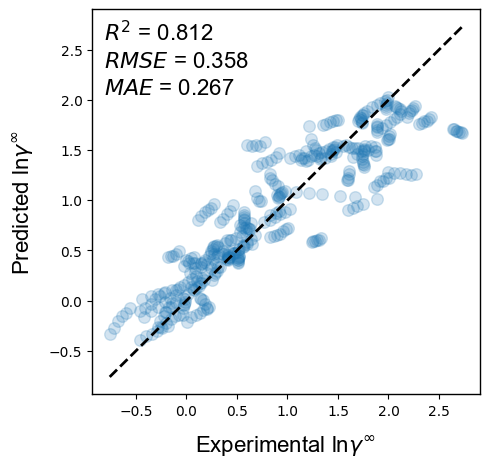

In [4]:
### plot the figure
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111)
for m in ['top', 'bottom', 'left', 'right']:
    ax.spines[m].set_linewidth(1)
    ax.spines[m].set_color('black')
ax.scatter(Y, cv_pred, 70, 'tab:blue', alpha=0.2)
ax.plot([Y.min(), Y.max()], [Y.min(), Y.max()], "k--", lw=2)
import matplotlib.font_manager as fm
fonts = fm.FontProperties(family='arial', size=16, weight='normal', style='normal')
plt.text(0.03, 0.92, '$R^2$ = {}'.format(str(round(R2_cv, 3))), transform=ax.transAxes, fontproperties=fonts)
plt.text(0.03, 0.85, '$RMSE$ = {}'.format(str(round(RMSE_cv, 3))), transform=ax.transAxes, fontproperties=fonts)
plt.text(0.03, 0.78, '$MAE$ = {}'.format(str(round(MAE_cv, 3))), transform=ax.transAxes, fontproperties=fonts)
plt.xlabel('Experimental ln$\gamma^{∞}$', labelpad=10, fontproperties=fonts)
plt.ylabel('Predicted ln$\gamma^{∞}$', labelpad=10, fontproperties=fonts)
import matplotlib.ticker as mticker
ticker_arg = [10, 20, 10, 20]
tickers = [mticker.MultipleLocator(ticker_arg[i]) for i in range(len(ticker_arg))]

